In [1]:
import random
from pathlib import Path
import os
import shutil

import numpy as np
import torch
from torch.utils.data import Dataset


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(42)

DATA_ROOT = Path(os.environ.get("PCB_DATA_ROOT", str(Path.cwd() / "DeepPCB"))).expanduser()
IMAGE_SIZE = 640
DATA_ROOT.mkdir(parents=True, exist_ok=True)
os.environ["KAGGLEHUB_CACHE"] = str(DATA_ROOT / ".kagglehub")

Có thể đổi `DATA_ROOT` qua biến môi trường `PCB_DATA_ROOT`; mặc định `IMAGE_SIZE=640` giữ nguyên ảnh gốc.

Thiết lập seed chung giúp các lần chạy có thể tái lập, còn RNG toàn cục tiếp tục sinh augmentation trong quá trình nạp dữ liệu.

In [2]:
SPLITS = ("train", "valid", "test")
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png"}

candidates = (DATA_ROOT, DATA_ROOT / "DeepPCB")
deep_pcb_base = next(
    (path.resolve() for path in candidates if all(
        (path / split / folder).is_dir()
        for split in SPLITS for folder in ("images", "labels")
    )),
    None,
)
if deep_pcb_base is None:
    raise FileNotFoundError(f"DeepPCB splits not found under {DATA_ROOT}")

PKU_DATA_ROOT = Path(os.environ.get(
    "PKU_DATA_ROOT", str(Path.cwd() / "PKU-Market-PCB(Data enhanced version)")
)).expanduser()
pku_base = PKU_DATA_ROOT.resolve()
if not all(
    (pku_base / split / folder).is_dir()
    for split in SPLITS for folder in ("images", "labels")
):
    raise FileNotFoundError(f"PKU splits not found under {PKU_DATA_ROOT}")

DATASET_ROOTS = {"DeepPCB": deep_pcb_base, "PKU": pku_base}
for source_name, source_root in DATASET_ROOTS.items():
    print(f"{source_name}: {source_root}")
    for split in SPLITS:
        split_dir = source_root / split
        image_count = sum(path.suffix.lower() in IMAGE_SUFFIXES for path in (split_dir / "images").iterdir())
        label_count = len(list((split_dir / "labels").glob("*.txt")))
        print(f"  {split}: {image_count} images, {label_count} labels")

sample_label = next((deep_pcb_base / "train" / "labels").glob("*.txt"), None)
pku_sample_label = next((pku_base / "train" / "labels").glob("*.txt"), None)
if sample_label is None or pku_sample_label is None:
    raise FileNotFoundError("Training annotations are missing from one of the datasets")
print("DeepPCB annotation example:", sample_label.read_text(encoding="utf-8").splitlines()[:3])
print("PKU YOLO annotation example:", pku_sample_label.read_text(encoding="utf-8").splitlines()[:3])

DeepPCB: D:\PCB_Multi Label Classification\DeepPCB
  train: 1200 images, 1200 labels
  valid: 150 images, 150 labels
  test: 150 images, 150 labels
PKU: D:\PCB_Multi Label Classification\PKU-Market-PCB(Data enhanced version)
  train: 2772 images, 2772 labels
  valid: 366 images, 366 labels
  test: 366 images, 366 labels
DeepPCB annotation example: ['466 441 493 470 3', '454 300 493 396 2', '331 248 364 283 4']
PKU YOLO annotation example: ['0 0.8221819380355966 0.8206179066834804 0.023401450230718525 0.03467843631778058', '0 0.5425181278839816 0.23013871374527112 0.021753460777851022 0.03909205548549811', '0 0.5805866842452209 0.519546027742749 0.023401450230718525 0.03783102143757881']


In [3]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageDraw, ImageOps

print(f"numpy={np.__version__} | pandas={pd.__version__}")

numpy=2.3.3 | pandas=2.3.3


## 1. Khám phá DeepPCB và kiểm tra annotation

In [4]:
CLASS_NAMES = [name.strip(" '\"") for name in (deep_pcb_base / "Class.txt").read_text(encoding="utf-8").strip().split(",")]
CLASS_ID_TO_INDEX = {class_id: class_id - 1 for class_id in range(1, len(CLASS_NAMES) + 1)}

box_cache = {}
annotation_errors = []


def read_boxes(label_path):
    label_path = Path(label_path)
    if label_path in box_cache:
        return box_cache[label_path]

    boxes = []
    if not label_path.exists():
        box_cache[label_path] = boxes
        return boxes

    for line_number, line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), 1):
        if not line.strip():
            continue
        values = line.split()
        if len(values) != 5:
            annotation_errors.append({
                "label_path": str(label_path), "line": line_number,
                "error": f"Expected 5 values, found {len(values)}",
            })
            continue
        try:
            x1, y1, x2, y2, class_id = map(int, values)
        except ValueError as error:
            annotation_errors.append({
                "label_path": str(label_path), "line": line_number,
                "error": f"Non-integer annotation: {error}",
            })
            continue
        if class_id not in CLASS_ID_TO_INDEX:
            annotation_errors.append({
                "label_path": str(label_path), "line": line_number,
                "error": f"Unknown class ID: {class_id}",
            })
            continue
        if x2 <= x1 or y2 <= y1:
            annotation_errors.append({
                "label_path": str(label_path), "line": line_number,
                "error": f"Invalid box extent: {values}",
            })
            continue
        class_index = CLASS_ID_TO_INDEX[class_id]
        boxes.append({
            "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            "class_id": class_id, "class_index": class_index,
            "class_name": CLASS_NAMES[class_index],
        })

    box_cache[label_path] = boxes
    return boxes


image_records, box_records = [], []
missing_label_files, unmatched_label_files = [], []
out_of_bounds_boxes = []
grayscale_image_count = 0
for split in SPLITS:
    images_dir, labels_dir = deep_pcb_base / split / "images", deep_pcb_base / split / "labels"
    image_paths = sorted(p for p in images_dir.iterdir() if p.suffix.lower() in IMAGE_SUFFIXES)
    image_stems = {p.stem for p in image_paths}
    unmatched_label_files.extend((split, p.name) for p in labels_dir.glob("*.txt") if p.stem not in image_stems)

    for image_path in image_paths:
        label_path = labels_dir / f"{image_path.stem}.txt"
        if not label_path.exists():
            missing_label_files.append((split, image_path.name))
        with Image.open(image_path) as source:
            width, height = source.size
            rgb = np.asarray(source.convert("RGB"))
        is_grayscale = np.array_equal(rgb[..., 0], rgb[..., 1]) and np.array_equal(rgb[..., 1], rgb[..., 2])
        grayscale_image_count += int(is_grayscale)

        boxes = read_boxes(label_path)
        for box in boxes:
            if not (0 <= box["x1"] < box["x2"] <= width and 0 <= box["y1"] < box["y2"] <= height):
                out_of_bounds_boxes.append({
                    "split": split, "image_name": image_path.name,
                    "class_name": box["class_name"],
                    "x1": box["x1"], "y1": box["y1"], "x2": box["x2"], "y2": box["y2"],
                    "image_width": width, "image_height": height,
                })

        target = np.zeros(len(CLASS_NAMES), dtype=np.float32)
        for box in boxes:
            target[box["class_index"]] = 1
        box_records.extend({
            "split": split, "image_name": image_path.name,
            "width": box["x2"] - box["x1"], "height": box["y2"] - box["y1"],
            "image_width": width, "image_height": height, **box,
        } for box in boxes)
        image_records.append({
            "split": split, "image_name": image_path.name,
            "image_path": image_path, "label_path": label_path,
            "image_width": width, "image_height": height,
            "num_boxes": len(boxes), "num_classes": int(target.sum()), "target": target,
        })

manifest, annotations = pd.DataFrame(image_records), pd.DataFrame(box_records)
print("Class order:", list(enumerate(CLASS_NAMES)))
print(f"Images: {len(manifest):,} | boxes: {len(annotations):,}")
print(f"Exactly grayscale (equal RGB channels): {grayscale_image_count}/{len(manifest)} images")
print(f"Annotation parse/format errors: {len(annotation_errors)}")
print(f"Out-of-bounds boxes: {len(out_of_bounds_boxes)}")
print(f"Images missing label files: {len(missing_label_files)} | labels without images: {len(unmatched_label_files)}")
if annotation_errors:
    display(pd.DataFrame(annotation_errors))
if out_of_bounds_boxes:
    display(pd.DataFrame(out_of_bounds_boxes))
display(manifest.groupby("split").size().rename("images").to_frame())

if not annotations.empty:
    size_measurements = {
        "Original width": annotations["width"],
        "Original height": annotations["height"],
        "Scaled width": annotations["width"] * IMAGE_SIZE / annotations["image_width"],
        "Scaled height": annotations["height"] * IMAGE_SIZE / annotations["image_height"],
    }
    box_size_summary = pd.DataFrame({
        name: {
            "minimum": values.min(),
            "p05": values.quantile(0.05),
            "p10": values.quantile(0.10),
            "p25": values.quantile(0.25),
        }
        for name, values in size_measurements.items()
    }).T
    display(box_size_summary.round(2))
    small_box_count = int((
        (size_measurements["Scaled width"] < 8)
        | (size_measurements["Scaled height"] < 8)
    ).sum())
    if small_box_count:
        print(f"WARNING: {small_box_count} boxes have width or height below 8 px after scaling to {IMAGE_SIZE}.")
    else:
        print(f"No boxes are below 8 px in width or height after scaling to {IMAGE_SIZE}.")

Class order: [(0, 'open'), (1, 'short'), (2, 'mousebite'), (3, 'spur'), (4, 'copper'), (5, 'pin-hole')]
Images: 1,500 | boxes: 10,013
Exactly grayscale (equal RGB channels): 1499/1500 images
Annotation parse/format errors: 0
Out-of-bounds boxes: 0
Images missing label files: 0 | labels without images: 0


,images
split,
test,150
train,1200
valid,150


,minimum,p05,p10,p25
Original width,18.0,27.0,28.0,31.0
Original height,19.0,25.0,26.0,29.0
Scaled width,18.0,27.0,28.0,31.0
Scaled height,19.0,25.0,26.0,29.0


No boxes are below 8 px in width or height after scaling to 640.


Annotation được cache; mọi lỗi format và box ngoài ảnh được thu thập trước khi tạo target, đồng thời EDA đo grayscale và kích thước box trước/sau scale.

DeepPCB có các split `train`, `valid`, `test`, mỗi ảnh đi kèm file annotation. Mỗi dòng annotation có dạng `x_min y_min x_max y_max class_id` (tọa độ pixel, class ID 1-based); một ảnh có thể có nhiều box thuộc nhiều lớp. Bài toán ở đây gán một nhãn multi-hot cho mỗi ảnh, không dùng softmax/argmax.

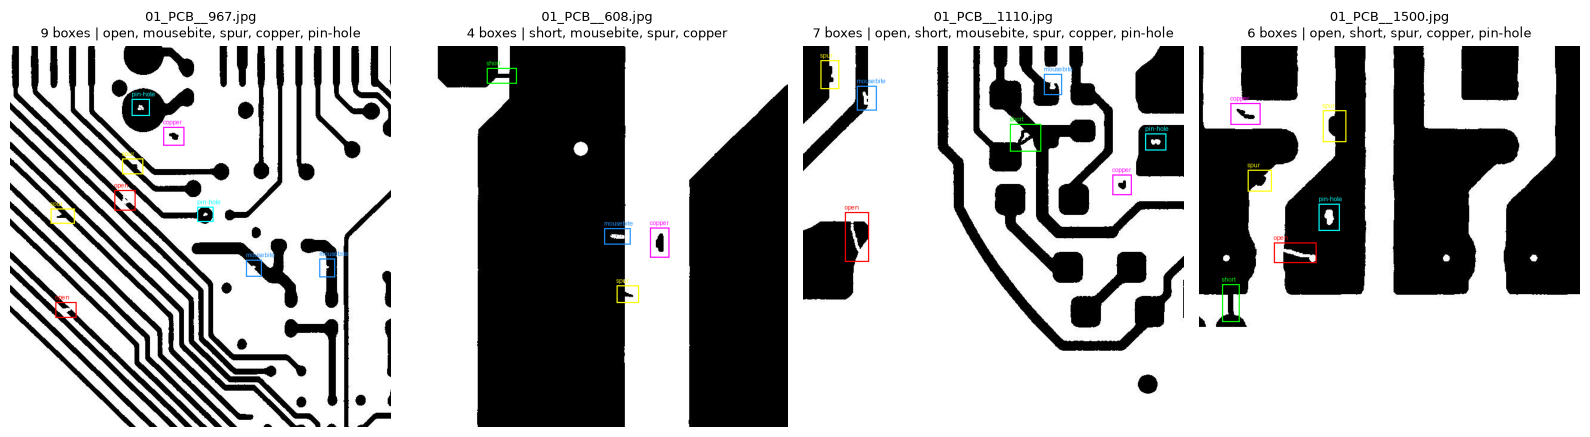

In [29]:
def show_annotated_samples(split="train", num_samples=4, random_state=42):
    samples = (
        manifest.loc[manifest["split"] == split]
        .sample(n=min(num_samples, int((manifest["split"] == split).sum())), random_state=random_state)
    )
    colors = ["red", "lime", "dodgerblue", "yellow", "magenta", "cyan"]
    figure, axes = plt.subplots(1, len(samples), figsize=(16, 5))
    axes = np.atleast_1d(axes)

    for axis, row in zip(axes, samples.itertuples()):
        image = Image.open(row.image_path).convert("RGB")
        draw = ImageDraw.Draw(image)
        boxes = read_boxes(row.label_path)
        for box in boxes:
            color = colors[box["class_index"]]
            draw.rectangle((box["x1"], box["y1"], box["x2"], box["y2"]), outline=color, width=2)
            draw.text((box["x1"], max(0, box["y1"] - 14)), box["class_name"], fill=color)

        class_names = [CLASS_NAMES[index] for index, value in enumerate(row.target) if value]
        axis.imshow(image)
        axis.set_title(f"{row.image_name}\n{len(boxes)} boxes | {', '.join(class_names)}", fontsize=9)
        axis.axis("off")

    figure.tight_layout()
    plt.show()

show_annotated_samples(num_samples=4)


### EDA finding

All images are 640x640. The annotations contain 10,013 defect boxes; a typical box is about 35x33 pixels. Most images contain several defect classes, so labels must be built per image as six-element multi-hot vectors. Resizing to 256x256 would shrink a typical defect to about 14x13 pixels; start with 512x512 and verify the smallest defects remain visible.

Image/box counts by class:


,images,boxes
open,1344,1942
short,1101,1506
mousebite,1269,1965
spur,1184,1625
copper,1241,1474
pin-hole,1315,1501


Image dimensions:


,,count
image_width,image_height,
640,640,1500


Boxes per image: {'count': 1500.0, 'mean': 6.68, 'std': 1.81, 'min': 1.0, '25%': 5.0, '50%': 7.0, '75%': 8.0, 'max': 15.0}
Classes per image: {1: 5, 2: 16, 3: 72, 4: 322, 5: 597, 6: 488}
Box size (pixels):


,width,height
count,10013.0,10013.0
mean,38.9,35.7
std,13.4,11.2
min,18.0,19.0
25%,31.0,29.0
50%,35.0,33.0
75%,42.0,39.0
90%,53.0,48.0
max,173.0,152.0


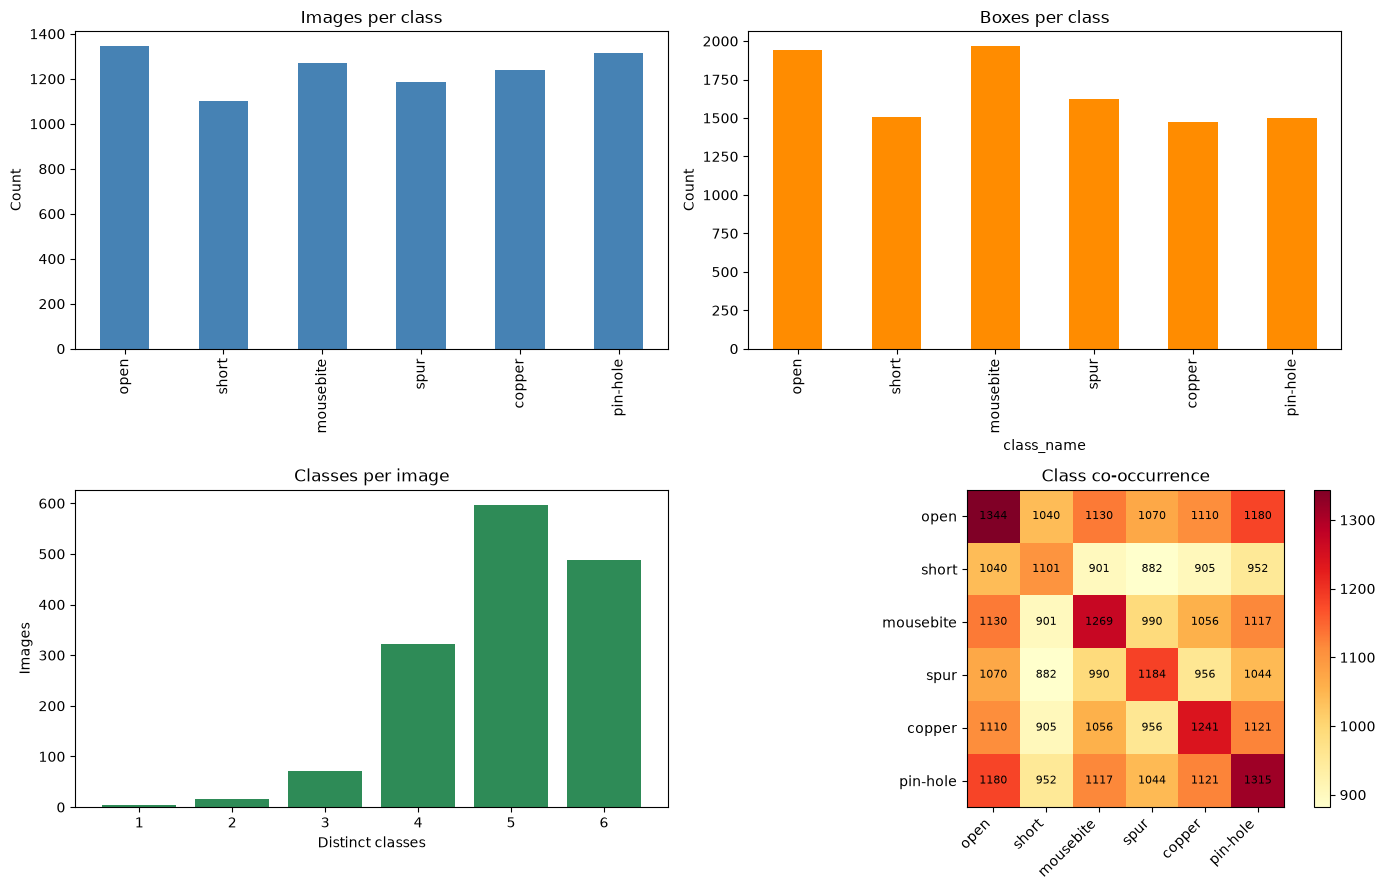

In [6]:
target_frame = pd.DataFrame(np.stack(manifest["target"]), columns=CLASS_NAMES)
image_class_counts = target_frame.sum().astype(int)
box_class_counts = annotations["class_name"].value_counts().reindex(CLASS_NAMES, fill_value=0)
cooccurrence = target_frame.T.dot(target_frame).astype(int)

print("Image/box counts by class:")
display(pd.DataFrame({"images": image_class_counts, "boxes": box_class_counts}))
print("Image dimensions:")
display(manifest.groupby(["image_width", "image_height"]).size().rename("count").to_frame())
print("Boxes per image:", manifest["num_boxes"].describe().round(2).to_dict())
print("Classes per image:", manifest["num_classes"].value_counts().sort_index().to_dict())
print("Box size (pixels):")
display(annotations[["width", "height"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(1))

figure, axes = plt.subplots(2, 2, figsize=(14, 9))
for axis, values, title, color in zip(
    axes.flat[:2], (image_class_counts, box_class_counts),
    ("Images per class", "Boxes per class"), ("steelblue", "darkorange")
):
    values.plot.bar(ax=axis, title=title, color=color)
    axis.set_ylabel("Count")

hist = manifest["num_classes"].value_counts().sort_index()
axes[1, 0].bar(hist.index, hist.values, color="seagreen")
axes[1, 0].set(title="Classes per image", xlabel="Distinct classes", ylabel="Images")

heatmap = axes[1, 1].imshow(cooccurrence, cmap="YlOrRd")
axes[1, 1].set(xticks=range(len(CLASS_NAMES)), xticklabels=CLASS_NAMES,
                yticks=range(len(CLASS_NAMES)), yticklabels=CLASS_NAMES, title="Class co-occurrence")
plt.setp(axes[1, 1].get_xticklabels(), rotation=45, ha="right")
for row, column in np.ndindex(cooccurrence.shape):
    axes[1, 1].text(column, row, cooccurrence.iloc[row, column], ha="center", va="center", fontsize=8)
figure.colorbar(heatmap, ax=axes[1, 1], fraction=0.046)
figure.tight_layout()
plt.show()

In [7]:
split_image_counts = manifest.groupby("split").size().reindex(SPLITS)
split_class_counts = target_frame.groupby(manifest["split"]).sum().reindex(SPLITS).astype(int)
split_class_prevalence = split_class_counts.div(split_image_counts, axis=0).round(3)
display(pd.concat({"positive images": split_class_counts, "prevalence": split_class_prevalence}, axis=1))

positive images                                      prevalence         \
                 open short mousebite spur copper pin-hole       open  short   
split                                                                          
train            1072   870      1014  952    997     1065      0.893  0.725   
valid             138   117       126  119    125      126      0.920  0.780   
test              134   114       129  113    119      124      0.893  0.760   

                                        
      mousebite   spur copper pin-hole  
split                                   
train     0.845  0.793  0.831    0.888  
valid     0.840  0.793  0.833    0.840  
test      0.860  0.753  0.793    0.827

PKU class order: [(0, 'Missing_hole'), (1, 'Mouse_bite'), (2, 'Open_circuit'), (3, 'Short'), (4, 'Spur'), (5, 'Spurious_copper')]
Images: 3,504 | boxes: 14,426
Image dimensions:
                          count
image_width image_height       
336         1446              1
448         1069              1
462         1450              1
491         1457              1
519         1061              1
...                         ...
2972        1281              1
2988        1036              1
2994        1656              1
3034        1586            432
3056        2464            435

[1408 rows x 1 columns]
Exactly grayscale: 0/3504 images
Annotation parse/format errors: 0
Out-of-bounds boxes: 0
Images missing label files: 0 | labels without images: 0


,images
split,
test,366
train,2772
valid,366


Image/box counts by class:


,images,boxes
Missing_hole,582,2434
Mouse_bite,582,2410
Open_circuit,586,2338
Short,586,2396
Spur,582,2386
Spurious_copper,586,2462


Boxes per image: {'count': 3504.0, 'mean': 4.12, 'std': 1.06, 'min': 1.0, '25%': 3.0, '50%': 5.0, '75%': 5.0, 'max': 6.0}
Classes per image: {1: 3504}
Box size in pixels:


,width,height
count,14426.0,14426.0
mean,70.1,66.8
std,28.2,24.0
min,24.0,23.0
25%,51.0,50.0
50%,64.0,62.0
75%,84.0,80.0
90%,107.0,98.0
max,283.0,215.0


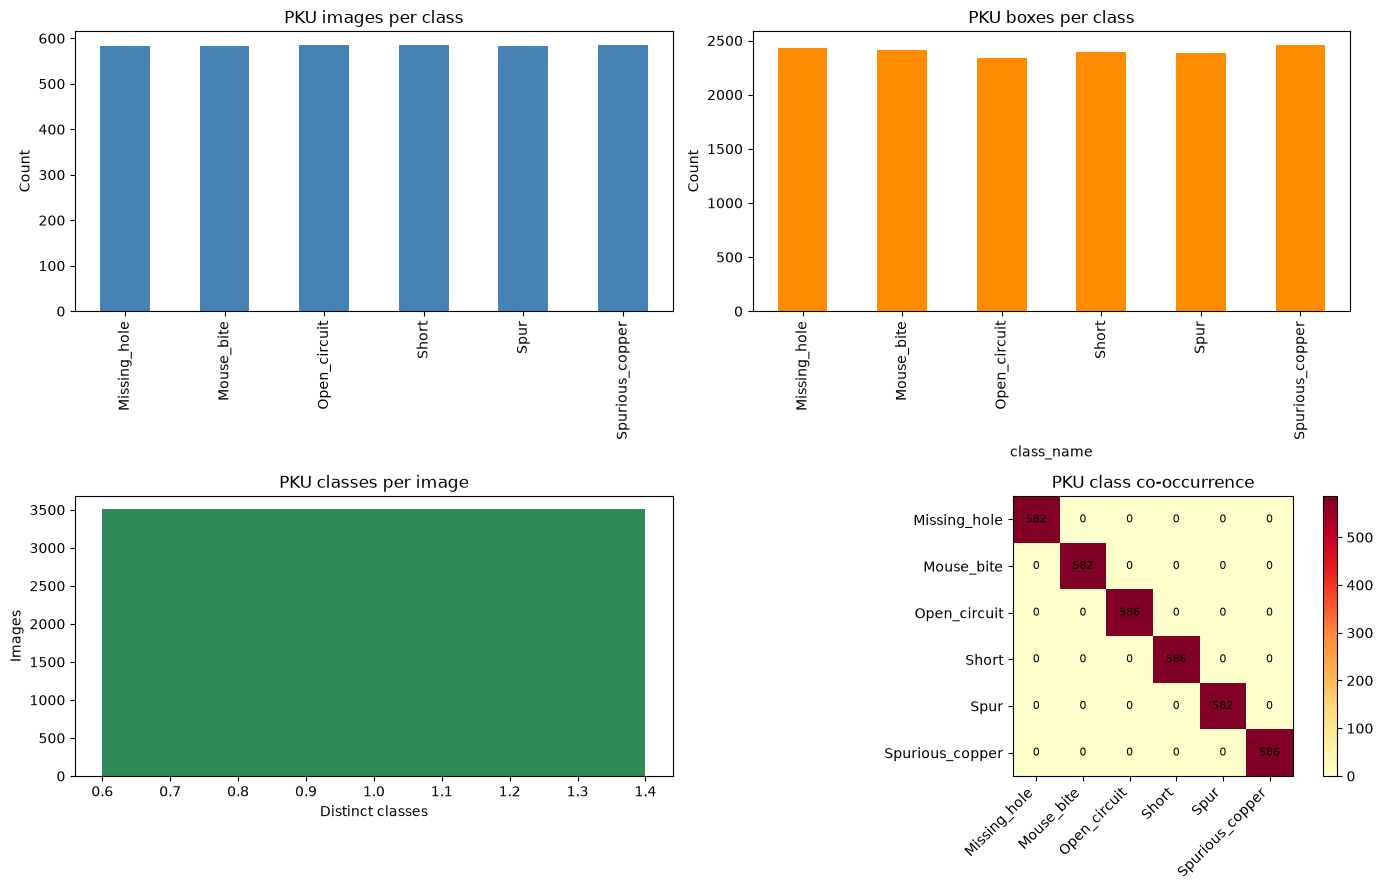

positive images                                                     \
         Missing_hole Mouse_bite Open_circuit Short Spur Spurious_copper   
split                                                                      
train             460        460          464   464  460             464   
valid              61         61           61    61   61              61   
test               61         61           61    61   61              61   

        prevalence                                                        
      Missing_hole Mouse_bite Open_circuit  Short   Spur Spurious_copper  
split                                                                     
train        0.166      0.166        0.167  0.167  0.166           0.167  
valid        0.167      0.167        0.167  0.167  0.167           0.167  
test         0.167      0.167        0.167  0.167  0.167           0.167

In [8]:
PKU_CLASS_NAMES = [
    name.strip(" '\"")
    for name in (pku_base / "Class.txt").read_text(encoding="utf-8").strip().split(",")
]
PKU_CLASS_ID_TO_INDEX = {class_id: class_id for class_id in range(len(PKU_CLASS_NAMES))}

pku_image_records, pku_box_records = [], []
pku_annotation_errors = []
pku_missing_label_files, pku_unmatched_label_files = [], []
pku_out_of_bounds_boxes = []
pku_grayscale_image_count = 0

for split in SPLITS:
    images_dir = pku_base / split / "images"
    labels_dir = pku_base / split / "labels"
    image_paths = sorted(p for p in images_dir.iterdir() if p.suffix.lower() in IMAGE_SUFFIXES)
    image_stems = {p.stem for p in image_paths}
    pku_unmatched_label_files.extend(
        (split, p.name) for p in labels_dir.glob("*.txt") if p.stem not in image_stems
    )

    for image_path in image_paths:
        label_path = labels_dir / f"{image_path.stem}.txt"
        if not label_path.exists():
            pku_missing_label_files.append((split, image_path.name))

        with Image.open(image_path) as source:
            width, height = source.size
            rgb = np.asarray(source.convert("RGB"))
        is_grayscale = np.array_equal(rgb[..., 0], rgb[..., 1]) and np.array_equal(rgb[..., 1], rgb[..., 2])
        pku_grayscale_image_count += int(is_grayscale)

        boxes = []
        if label_path.exists():
            for line_number, line in enumerate(label_path.read_text(encoding="utf-8").splitlines(), 1):
                if not line.strip():
                    continue
                values = line.split()
                if len(values) != 5:
                    pku_annotation_errors.append({
                        "label_path": str(label_path), "line": line_number,
                        "error": f"Expected 5 values, found {len(values)}",
                    })
                    continue
                try:
                    class_id = int(values[0])
                    center_x, center_y, box_width, box_height = map(float, values[1:])
                except ValueError as error:
                    pku_annotation_errors.append({
                        "label_path": str(label_path), "line": line_number,
                        "error": f"Invalid YOLO values: {error}",
                    })
                    continue
                normalized_values = (center_x, center_y, box_width, box_height)
                if class_id not in PKU_CLASS_ID_TO_INDEX:
                    pku_annotation_errors.append({
                        "label_path": str(label_path), "line": line_number,
                        "error": f"Unknown class ID: {class_id}",
                    })
                    continue
                if not np.isfinite(normalized_values).all() or not (0 <= center_x <= 1 and 0 <= center_y <= 1 and 0 < box_width <= 1 and 0 < box_height <= 1):
                    pku_annotation_errors.append({
                        "label_path": str(label_path), "line": line_number,
                        "error": f"Invalid normalized box: {values}",
                    })
                    continue

                x1 = (center_x - box_width / 2) * width
                y1 = (center_y - box_height / 2) * height
                x2 = (center_x + box_width / 2) * width
                y2 = (center_y + box_height / 2) * height
                class_index = PKU_CLASS_ID_TO_INDEX[class_id]
                box = {
                    "x1": x1, "y1": y1, "x2": x2, "y2": y2,
                    "width": x2 - x1, "height": y2 - y1,
                    "class_id": class_id, "class_index": class_index,
                    "class_name": PKU_CLASS_NAMES[class_index],
                }
                boxes.append(box)
                if not (0 <= x1 < x2 <= width and 0 <= y1 < y2 <= height):
                    pku_out_of_bounds_boxes.append({
                        "split": split, "image_name": image_path.name,
                        "class_name": box["class_name"], "x1": x1, "y1": y1, "x2": x2, "y2": y2,
                        "image_width": width, "image_height": height,
                    })

        target = np.zeros(len(PKU_CLASS_NAMES), dtype=np.float32)
        for box in boxes:
            target[box["class_index"]] = 1
        pku_box_records.extend({
            "split": split, "image_name": image_path.name,
            "image_width": width, "image_height": height, **box,
        } for box in boxes)
        pku_image_records.append({
            "split": split, "image_name": image_path.name,
            "image_path": image_path, "label_path": label_path,
            "image_width": width, "image_height": height,
            "num_boxes": len(boxes), "num_classes": int(target.sum()), "target": target,
        })

pku_manifest = pd.DataFrame(pku_image_records)
pku_annotations = pd.DataFrame(pku_box_records)
print("PKU class order:", list(enumerate(PKU_CLASS_NAMES)))
print(f"Images: {len(pku_manifest):,} | boxes: {len(pku_annotations):,}")
print(f"Image dimensions:\n{pku_manifest.groupby(['image_width', 'image_height']).size().rename('count').to_frame()}")
print(f"Exactly grayscale: {pku_grayscale_image_count}/{len(pku_manifest)} images")
print(f"Annotation parse/format errors: {len(pku_annotation_errors)}")
print(f"Out-of-bounds boxes: {len(pku_out_of_bounds_boxes)}")
print(f"Images missing label files: {len(pku_missing_label_files)} | labels without images: {len(pku_unmatched_label_files)}")
if pku_annotation_errors:
    display(pd.DataFrame(pku_annotation_errors).head(20))
if pku_out_of_bounds_boxes:
    display(pd.DataFrame(pku_out_of_bounds_boxes).head(20))
display(pku_manifest.groupby("split").size().rename("images").to_frame())

pku_target_frame = pd.DataFrame(np.stack(pku_manifest["target"]), columns=PKU_CLASS_NAMES)
pku_image_class_counts = pku_target_frame.sum().astype(int)
pku_box_class_counts = pku_annotations["class_name"].value_counts().reindex(PKU_CLASS_NAMES, fill_value=0)
pku_cooccurrence = pku_target_frame.T.dot(pku_target_frame).astype(int)
print("Image/box counts by class:")
display(pd.DataFrame({"images": pku_image_class_counts, "boxes": pku_box_class_counts}))
print("Boxes per image:", pku_manifest["num_boxes"].describe().round(2).to_dict())
print("Classes per image:", pku_manifest["num_classes"].value_counts().sort_index().to_dict())
print("Box size in pixels:")
display(pku_annotations[["width", "height"]].describe(percentiles=[0.25, 0.5, 0.75, 0.9]).round(1))

figure, axes = plt.subplots(2, 2, figsize=(14, 9))
for axis, values, title, color in zip(
    axes.flat[:2], (pku_image_class_counts, pku_box_class_counts),
    ("PKU images per class", "PKU boxes per class"), ("steelblue", "darkorange")
):
    values.plot.bar(ax=axis, title=title, color=color)
    axis.set_ylabel("Count")

pku_hist = pku_manifest["num_classes"].value_counts().sort_index()
axes[1, 0].bar(pku_hist.index, pku_hist.values, color="seagreen")
axes[1, 0].set(title="PKU classes per image", xlabel="Distinct classes", ylabel="Images")

heatmap = axes[1, 1].imshow(pku_cooccurrence, cmap="YlOrRd")
axes[1, 1].set(xticks=range(len(PKU_CLASS_NAMES)), xticklabels=PKU_CLASS_NAMES,
                yticks=range(len(PKU_CLASS_NAMES)), yticklabels=PKU_CLASS_NAMES,
                title="PKU class co-occurrence")
plt.setp(axes[1, 1].get_xticklabels(), rotation=45, ha="right")
for row, column in np.ndindex(pku_cooccurrence.shape):
    axes[1, 1].text(column, row, pku_cooccurrence.iloc[row, column], ha="center", va="center", fontsize=8)
figure.colorbar(heatmap, ax=axes[1, 1], fraction=0.046)
figure.tight_layout()
plt.show()

pku_split_image_counts = pku_manifest.groupby("split").size().reindex(SPLITS)
pku_split_class_counts = pku_target_frame.groupby(pku_manifest["split"]).sum().reindex(SPLITS).astype(int)
pku_split_class_prevalence = pku_split_class_counts.div(pku_split_image_counts, axis=0).round(3)
display(pd.concat({"positive images": pku_split_class_counts, "prevalence": pku_split_class_prevalence}, axis=1))

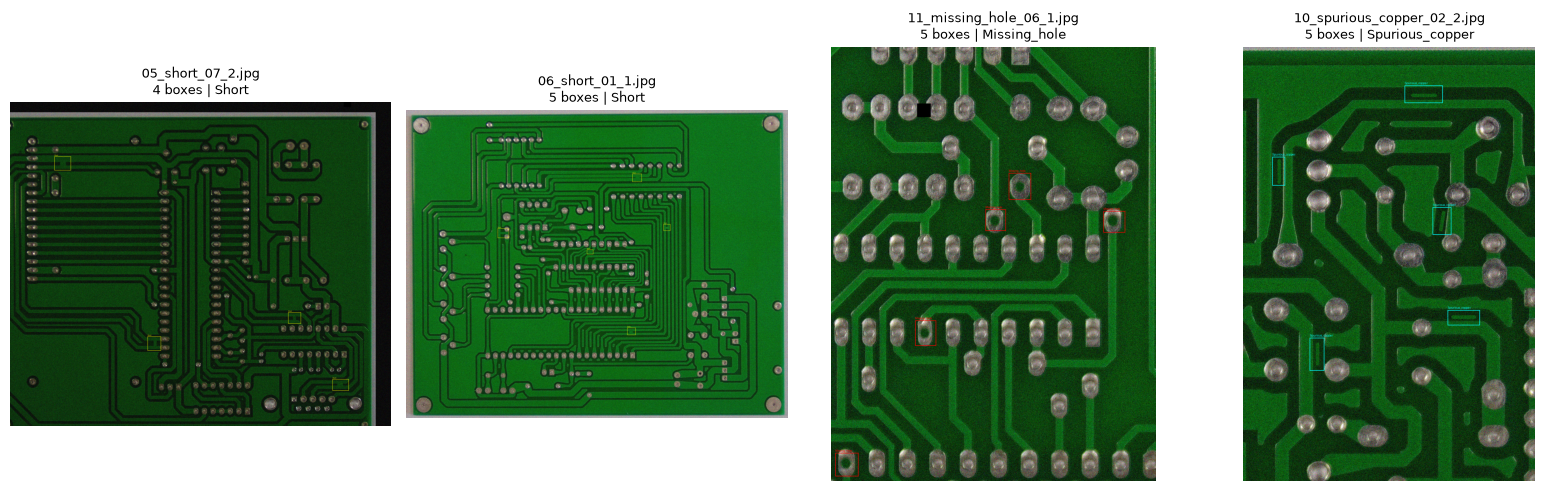

In [9]:
def show_pku_annotated_samples(split="train", num_samples=4, random_state=42):
    samples = pku_manifest.loc[pku_manifest["split"] == split].sample(
        n=min(num_samples, int((pku_manifest["split"] == split).sum())),
        random_state=random_state,
    )
    colors = ["red", "lime", "dodgerblue", "yellow", "magenta", "cyan"]
    figure, axes = plt.subplots(1, len(samples), figsize=(16, 5))
    axes = np.atleast_1d(axes)

    for axis, row in zip(axes, samples.itertuples()):
        image = Image.open(row.image_path).convert("RGB")
        draw = ImageDraw.Draw(image)
        boxes = []
        for line in row.label_path.read_text(encoding="utf-8").splitlines():
            if not line.strip():
                continue
            class_id, center_x, center_y, box_width, box_height = line.split()
            class_id = int(class_id)
            center_x, center_y, box_width, box_height = map(
                float, (center_x, center_y, box_width, box_height)
            )
            x1 = (center_x - box_width / 2) * row.image_width
            y1 = (center_y - box_height / 2) * row.image_height
            x2 = (center_x + box_width / 2) * row.image_width
            y2 = (center_y + box_height / 2) * row.image_height
            boxes.append((class_id, x1, y1, x2, y2))
            color = colors[class_id]
            draw.rectangle((x1, y1, x2, y2), outline=color, width=2)
            draw.text((x1, max(0, y1 - 14)), PKU_CLASS_NAMES[class_id], fill=color)

        class_names = [PKU_CLASS_NAMES[index] for index, value in enumerate(row.target) if value]
        axis.imshow(image)
        axis.set_title(f"{row.image_name}\n{len(boxes)} boxes | {', '.join(class_names)}", fontsize=9)
        axis.axis("off")

    figure.tight_layout()
    plt.show()


show_pku_annotated_samples(num_samples=4)

## 2. Khám phá PKU-Market-PCB (Data enhanced version)

PKU dùng annotation YOLO normalized dạng `class_id center_x center_y width height`, với class ID 0-based. Phần dưới chuyển box về tọa độ pixel để kiểm tra chất lượng annotation và so sánh phân bố dữ liệu với DeepPCB.

In [35]:
import hashlib

out_of_bounds = out_of_bounds_boxes
name_sets = {split: set(manifest.loc[manifest.split == split, "image_name"]) for split in SPLITS}
name_overlap = any(name_sets[a] & name_sets[b] for a, b in (("train", "valid"), ("train", "test"), ("valid", "test")))
hashes = {}
for row in manifest.itertuples():
    digest = hashlib.sha256(row.image_path.read_bytes()).hexdigest()
    hashes.setdefault(digest, set()).add(row.split)
content_overlap = any(len(splits) > 1 for splits in hashes.values())

print(f"Out-of-bounds boxes: {len(out_of_bounds)}")
print(f"Duplicate filenames/content across splits: {name_overlap}/{content_overlap}")

Out-of-bounds boxes: 0
Duplicate filenames/content across splits: False/False


PKU EDA tạo target multi-hot theo ảnh từ mọi YOLO box, đồng thời kiểm tra tọa độ normalized sau khi quy đổi về pixel.

Cell leakage dùng lại kết quả OOB đã cache trong lúc dựng manifest, tránh parse annotation lần thứ hai.

In [36]:
from itertools import combinations

import imagehash

DHASH_MAX_DISTANCE = 4
dhash_by_split = {split: [] for split in SPLITS}
for row in manifest.itertuples():
    with Image.open(row.image_path) as source:
        perceptual_hash = int(str(imagehash.dhash(source.convert("RGB"), hash_size=8)), 16)
    dhash_by_split[row.split].append((row.image_name, perceptual_hash))

near_duplicate_counts = []
near_duplicate_examples = []
for left_split, right_split in combinations(SPLITS, 2):
    pair_matches = []
    for left_name, left_hash in dhash_by_split[left_split]:
        for right_name, right_hash in dhash_by_split[right_split]:
            distance = (left_hash ^ right_hash).bit_count()
            if distance <= DHASH_MAX_DISTANCE:
                pair_matches.append({
                    "left_split": left_split,
                    "left_image": left_name,
                    "right_split": right_split,
                    "right_image": right_name,
                    "hamming_distance": distance,
                })
    near_duplicate_counts.append({
        "split_pair": f"{left_split}/{right_split}",
        "near_duplicate_pairs": len(pair_matches),
    })
    near_duplicate_examples.extend(pair_matches)

print(f"dHash near-duplicate pairs (Hamming distance <= {DHASH_MAX_DISTANCE}):")
display(pd.DataFrame(near_duplicate_counts))
if near_duplicate_examples:
    examples = sorted(near_duplicate_examples, key=lambda item: item["hamming_distance"])[:10]
    print("Closest matching pairs (up to 10):")
    display(pd.DataFrame(examples))
else:
    print("No cross-split near-duplicate pairs found at this threshold.")

dHash near-duplicate pairs (Hamming distance <= 4):


,split_pair,near_duplicate_pairs
0,train/valid,13
1,train/test,14
2,valid/test,0


Closest matching pairs (up to 10):


,left_split,left_image,right_split,right_image,hamming_distance
0,train,01_PCB__1463.jpg,valid,01_PCB__1459.jpg,1
1,train,01_PCB__647.jpg,valid,01_PCB__648.jpg,1
2,train,01_PCB__1399.jpg,test,01_PCB__1395.jpg,1
3,train,01_PCB__1403.jpg,test,01_PCB__1395.jpg,1
4,train,01_PCB__858.jpg,test,01_PCB__857.jpg,1
5,train,01_PCB__644.jpg,valid,01_PCB__648.jpg,2
6,train,01_PCB__650.jpg,valid,01_PCB__648.jpg,2
7,train,01_PCB__1155.jpg,test,01_PCB__1187.jpg,2
8,train,01_PCB__1475.jpg,test,01_PCB__1427.jpg,2
9,train,01_PCB__1124.jpg,valid,01_PCB__1156.jpg,3


dHash so sánh cấu trúc ảnh theo khoảng cách Hamming `<= 4`; các cặp được báo cáo để rà soát, không tự loại bỏ mẫu.

In [37]:
GROUP_PREFIX_PATTERN = r"^(.+?)__"
group_manifest = manifest.assign(
    group_code=manifest["image_name"].str.extract(GROUP_PREFIX_PATTERN, expand=False)
)
recognized_images = int(group_manifest["group_code"].notna().sum())

print(f"Filename prefix rule: text before '__' | identified images: {recognized_images}/{len(group_manifest)}")
if recognized_images == 0:
    print("No consistent group/board prefix found with this rule.")
else:
    group_report = (
        group_manifest.dropna(subset=["group_code"])
        .groupby("group_code")
        .agg(
            split_count=("split", "nunique"),
            splits=("split", lambda values: ", ".join(sorted(set(values)))),
            image_count=("image_name", "size"),
        )
    )
    cross_split_groups = group_report.loc[group_report["split_count"] > 1].sort_values(
        ["split_count", "image_count"], ascending=False
    )
    print(f"Group/board codes appearing in multiple splits: {len(cross_split_groups)}")
    if cross_split_groups.empty:
        print("No group codes span multiple splits.")
    else:
        display(cross_split_groups)

Filename prefix rule: text before '__' | identified images: 1500/1500
Group/board codes appearing in multiple splits: 1


,split_count,splits,image_count
group_code,,,
01_PCB,3,"test, train, valid",1500


Tiền tố trước `__` được dùng làm mã bo mạch; mã xuất hiện ở nhiều split được liệt kê để đánh giá nguy cơ leakage theo nhóm.

In [38]:
import importlib
import importlib.util


def _validate_multilabel_arrays(y_true, y_prob):
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob, dtype=np.float64)
    if y_true.ndim != 2 or y_prob.shape != y_true.shape or not y_true.size:
        raise ValueError("y_true and y_prob must have the same non-empty 2D shape")
    if not np.isin(y_true, (0, 1)).all():
        raise ValueError("y_true must contain only binary labels")
    if not np.isfinite(y_prob).all() or np.any((y_prob < 0) | (y_prob > 1)):
        raise ValueError("y_prob must contain finite probabilities in [0, 1]")
    return y_true.astype(np.uint8), y_prob


def _average_precision_binary(labels, scores):
    positive_count = int(labels.sum())
    if positive_count == 0:
        return np.nan
    order = np.argsort(-scores, kind="mergesort")
    sorted_scores = scores[order]
    sorted_labels = labels[order]
    group_ends = np.r_[np.flatnonzero(sorted_scores[:-1] != sorted_scores[1:]), len(labels) - 1]
    cumulative_true_positive = np.cumsum(sorted_labels)[group_ends]
    precision_at_group = cumulative_true_positive / (group_ends + 1)
    recall_increments = np.diff(np.r_[0, cumulative_true_positive]) / positive_count
    return float(np.sum(recall_increments * precision_at_group))


def _roc_auc_binary(labels, scores):
    positive_count = int(labels.sum())
    negative_count = len(labels) - positive_count
    if positive_count == 0 or negative_count == 0:
        return np.nan
    order = np.argsort(scores, kind="mergesort")
    sorted_scores = scores[order]
    group_starts = np.r_[0, np.flatnonzero(sorted_scores[:-1] != sorted_scores[1:]) + 1]
    group_ends = np.r_[group_starts[1:], len(labels)]
    average_ranks = (group_starts + 1 + group_ends) / 2
    ranks = np.empty(len(labels), dtype=np.float64)
    for start, end, rank in zip(group_starts, group_ends, average_ranks):
        ranks[order[start:end]] = rank
    rank_sum = ranks[labels == 1].sum()
    return float((rank_sum - positive_count * (positive_count + 1) / 2) / (positive_count * negative_count))


def evaluate_multilabel(y_true, y_prob, thresholds):
    y_true, y_prob = _validate_multilabel_arrays(y_true, y_prob)
    thresholds = np.asarray(thresholds, dtype=np.float64)
    if thresholds.ndim == 0:
        thresholds = np.full(y_true.shape[1], thresholds.item())
    if thresholds.shape != (y_true.shape[1],) or not np.isfinite(thresholds).all():
        raise ValueError("thresholds must be finite and scalar or one value per class")
    if np.any((thresholds < 0) | (thresholds > 1)):
        raise ValueError("thresholds must be in [0, 1]")

    y_pred = (y_prob >= thresholds[None, :]).astype(np.uint8)
    true_positive = (y_true & y_pred).sum(axis=0).astype(np.float64)
    predicted_positive = y_pred.sum(axis=0).astype(np.float64)
    actual_positive = y_true.sum(axis=0).astype(np.float64)
    precision = np.divide(true_positive, predicted_positive, out=np.zeros_like(true_positive), where=predicted_positive > 0)
    recall = np.divide(true_positive, actual_positive, out=np.zeros_like(true_positive), where=actual_positive > 0)
    class_f1 = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(precision), where=(precision + recall) > 0)
    class_ap = np.array([
        _average_precision_binary(y_true[:, index], y_prob[:, index])
        for index in range(y_true.shape[1])
    ])
    class_auc = np.array([
        _roc_auc_binary(y_true[:, index], y_prob[:, index])
        for index in range(y_true.shape[1])
    ])
    class_names = CLASS_NAMES if len(CLASS_NAMES) == y_true.shape[1] else [
        f"class_{index}" for index in range(y_true.shape[1])
    ]
    per_class = pd.DataFrame({
        "precision": precision,
        "recall": recall,
        "f1": class_f1,
        "average_precision": class_ap,
        "roc_auc": class_auc,
    }, index=pd.Index(class_names, name="class_name"))
    micro_tp = float(true_positive.sum())
    micro_predicted = float(predicted_positive.sum())
    micro_actual = float(actual_positive.sum())
    micro_precision = micro_tp / micro_predicted if micro_predicted else 0.0
    micro_recall = micro_tp / micro_actual if micro_actual else 0.0
    micro_f1 = 2 * micro_precision * micro_recall / (micro_precision + micro_recall) if micro_precision + micro_recall else 0.0

    return {
        "macro_f1": float(class_f1.mean()),
        "micro_f1": float(micro_f1),
        "exact_match": float(np.all(y_true == y_pred, axis=1).mean()),
        "per_class": per_class,
        "per_class_ap": class_ap,
        "macro_map": float(np.nanmean(class_ap)) if np.isfinite(class_ap).any() else np.nan,
        "per_class_roc_auc": class_auc,
    }


def select_thresholds_by_f1(y_true, y_prob):
    y_true, y_prob = _validate_multilabel_arrays(y_true, y_prob)
    thresholds = np.empty(y_true.shape[1], dtype=np.float32)
    for class_index in range(y_true.shape[1]):
        labels = y_true[:, class_index]
        scores = y_prob[:, class_index]
        candidates = np.unique(np.concatenate((scores, [0.0, 0.5, 1.0])))
        true_positive = np.array([(labels & (scores >= value)).sum() for value in candidates], dtype=np.float64)
        predicted_positive = np.array([(scores >= value).sum() for value in candidates], dtype=np.float64)
        actual_positive = float(labels.sum())
        precision = np.divide(true_positive, predicted_positive, out=np.zeros_like(true_positive), where=predicted_positive > 0)
        recall = true_positive / actual_positive if actual_positive else np.zeros_like(true_positive)
        f1_values = np.divide(2 * precision * recall, precision + recall, out=np.zeros_like(precision), where=(precision + recall) > 0)
        best_candidates = candidates[np.isclose(f1_values, f1_values.max())]
        thresholds[class_index] = best_candidates[np.argmin(np.abs(best_candidates - 0.5))]
    return thresholds


def bootstrap_multilabel_ci(y_true, y_prob, thresholds, n_bootstrap=1000, confidence=0.95, seed=42):
    y_true, y_prob = _validate_multilabel_arrays(y_true, y_prob)
    if n_bootstrap < 2 or not 0 < confidence < 1:
        raise ValueError("n_bootstrap must be >= 2 and confidence must be in (0, 1)")

    def flatten(metrics):
        values = {
            ("macro_f1", "all"): metrics["macro_f1"],
            ("micro_f1", "all"): metrics["micro_f1"],
            ("exact_match", "all"): metrics["exact_match"],
            ("macro_map", "all"): metrics["macro_map"],
        }
        for class_name, row in metrics["per_class"].iterrows():
            for metric_name, value in row.items():
                values[(metric_name, class_name)] = value
        return values

    point_estimates = flatten(evaluate_multilabel(y_true, y_prob, thresholds))
    bootstrap_values = {key: [] for key in point_estimates}
    rng = np.random.default_rng(seed)
    for _ in range(n_bootstrap):
        indices = rng.integers(0, len(y_true), size=len(y_true))
        sampled = flatten(evaluate_multilabel(y_true[indices], y_prob[indices], thresholds))
        for key, value in sampled.items():
            bootstrap_values[key].append(value)

    alpha = (1 - confidence) / 2
    results = []
    for (metric_name, class_name), estimate in point_estimates.items():
        values = np.asarray(bootstrap_values[(metric_name, class_name)], dtype=np.float64)
        values = values[np.isfinite(values)]
        lower, upper = np.quantile(values, [alpha, 1 - alpha]) if values.size else (np.nan, np.nan)
        results.append({
            "metric": metric_name,
            "class": class_name,
            "estimate": estimate,
            "ci_lower": lower,
            "ci_upper": upper,
            "confidence": confidence,
            "valid_bootstrap_samples": len(values),
        })
    return pd.DataFrame(results)


def count_model_complexity(model, input_shape=None):
    input_shape = input_shape or (3, IMAGE_SIZE, IMAGE_SIZE)
    parameters = list(model.parameters())
    parameter_count = sum(parameter.numel() for parameter in parameters)
    trainable_count = sum(parameter.numel() for parameter in parameters if parameter.requires_grad)
    first_parameter = parameters[0] if parameters else None
    device = first_parameter.device if first_parameter is not None else torch.device("cpu")
    dtype = first_parameter.dtype if first_parameter is not None and first_parameter.is_floating_point() else torch.float32
    result = {
        "parameters": int(parameter_count),
        "trainable_parameters": int(trainable_count),
        "flops": None,
        "macs": None,
        "complexity_tool": None,
    }
    was_training = model.training
    try:
        model.eval()
        sample = torch.zeros((1, *input_shape), device=device, dtype=dtype)
        if importlib.util.find_spec("fvcore") is not None:
            flop_counter = importlib.import_module("fvcore.nn").FlopCountAnalysis
            result["flops"] = int(flop_counter(model, sample).total())
            result["complexity_tool"] = "fvcore"
        elif importlib.util.find_spec("thop") is not None:
            profiler = importlib.import_module("thop").profile
            result["macs"] = int(profiler(model, inputs=(sample,), verbose=False)[0])
            result["complexity_tool"] = "thop (MACs)"
    except Exception as error:
        result["complexity_error"] = str(error)
    finally:
        model.train(was_training)
    return result

Các helper tách chọn threshold trên validation khỏi bootstrap CI trên test; FLOPs dùng `fvcore` nếu có, còn `thop` báo MACs.

## 3. Quy ước khi so sánh model

- So sánh đúng bốn cấu hình: Simple CNN, Complex CNN, ResNet18 train from scratch và ResNet18 pretrained. Cả bốn dùng cùng ảnh RGB `(3, 640, 640)`, split train/valid/test và augmentation flip/rot90 chỉ trên train. Scratch models dùng `dataset` normalization; ResNet18 pretrained dùng ImageNet normalization theo pretrained weights.
- Dùng cùng `BCEWithLogitsLoss(pos_weight=POS_WEIGHT)`, AdamW (`lr=3e-4`, `weight_decay=1e-4`), batch size 8 và tối đa 50 epochs cho cả bốn cấu hình.
- Dùng cùng `ReduceLROnPlateau` theo validation loss (`factor=0.5`, `patience=3`, `min_lr=1e-6`) và early stopping theo validation loss (`patience=8`, `min_delta=1e-4`); lưu checkpoint có validation loss tốt nhất.
- Với mỗi checkpoint tốt nhất, chọn threshold từng lớp bằng F1 tối đa trên valid; sau đó chỉ đánh giá test một lần cho mỗi run. Báo cáo macro/micro-F1, per-class precision/recall/F1/AP, macro-mAP, per-class ROC-AUC, exact-match, baseline và bootstrap CI 95% trên test.
- Chạy mỗi cấu hình với ít nhất ba seed cố định (ví dụ `42, 123, 2025`) và báo cáo mean ± std giữa các seed. Báo số parameters và FLOPs; nếu chỉ có `thop`, ghi rõ MACs thay cho FLOPs.
- Báo riêng kết quả ResNet18 pretrained vì pretraining là khác biệt về nguồn khởi tạo. Đây là phân loại sự hiện diện lỗi ở cấp ảnh, không dự đoán vị trí; box nhỏ (median khoảng 35x33 px), nên mục tiêu định vị cần detection/segmentation.